In [ ]:
import torch
import torchvision
torch.hub.set_dir("../model_cache/torch/hub")
import sys
import numpy as np
sys.path.append("/mnt/home/mizrahiulysse/ElasticDino")
from elasticdino.model.elasticdino import ElasticDino


%load_ext autoreload 
%autoreload 2
    
dataset = torchvision.datasets.Sintel("/mnt/home/mizrahiulysse/datasets")

In [34]:
import elasticdino.training.optical_flow as flow_transforms
import cv2

transform = flow_transforms.Compose([
    flow_transforms.ToTensor(),
    flow_transforms.RandomRotate(angle=20, diff_angle=15),
    flow_transforms.RandomTranslate(translation=(15, 15)),
    flow_transforms.RandomScale(range_min=0.9, range_max=2),
    # flow_transforms.RandomCrop(size=(300, 300)),
    flow_transforms.RandomHorizontalFlip(),
    flow_transforms.RandomVerticalFlip(),
    flow_transforms.AddGaussianNoise(stdev=5),
    flow_transforms.RandomMultiplicativeColor(range_min=0.9, range_max=1.1, independent=True),
    flow_transforms.RandomGammaColor(range_min=0.75, range_max=1.5, pixel_min=0, pixel_max=255, independent=True),
])


def augment(img1, img2, flow):
    img1 = np.array(img1)
    img2 = np.array(img2)
    flow = flow.transpose((1, 2, 0))
    (img1, img2), flow = transform([img1, img2], [flow])
    l = min(img1.shape[-1], img1.shape[-2])
    img1 = torch.nn.functional.interpolate(img1[:, :l, :l].unsqueeze(0), 128, mode="bilinear")
    img2 = torch.nn.functional.interpolate(img2[:, :l, :l].unsqueeze(0), 128, mode="bilinear")
    flow = torch.nn.functional.interpolate(flow[:, :l, :l], 128, mode="bilinear")
    return img1.clamp(0, 255), img2.clamp(0, 255), flow

def collate(batch):
    augmented = [augment(*x) for x in batch]
    imgs1 = torch.cat([x[0] for x in augmented]) / 255.0
    imgs2 = torch.cat([x[1] for x in augmented]) / 255.0
    flows = torch.cat([x[2] for x in augmented]) / 100.0
    imgs1 = torch.where(torch.isnan(imgs1), 0.0, imgs1)
    imgs2 = torch.where(torch.isnan(imgs2), 0.0, imgs2)
    flows = torch.where(torch.isnan(flows), 0.0, flows)
    return imgs1, imgs2, flows

In [ ]:

def get_edino():
    edino = ElasticDino.from_pretrained("/mnt/home/mizrahiulysse/pixelvit-32-L.pth", "elasticdino-32-L", dino_repo="/mnt/home/mizrahiulysse/model_cache/torch/hub/facebookresearch_dinov2_main")
    edino.eval()
    ed_config = edino.config
    edino.requires_grad_ = False
    return edino

edino = torch.compile(get_edino().cuda())

epoch 0
tensor(2.0302, device='cuda:0')


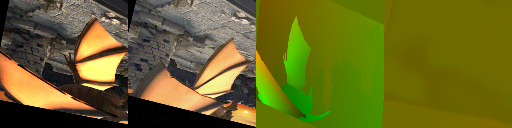

tensor(1.7530, device='cuda:0')


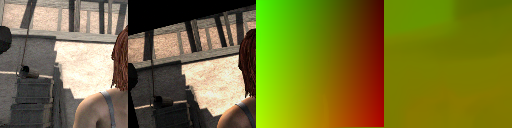

epoch 1
tensor(1.7609, device='cuda:0')


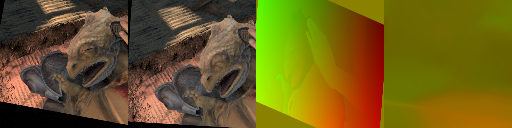

tensor(1.5246, device='cuda:0')


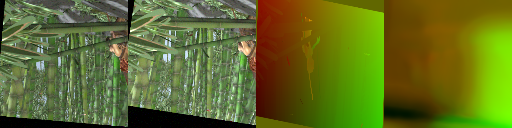

tensor(1.4344, device='cuda:0')


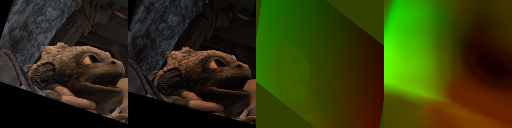

epoch 2
tensor(1.2278, device='cuda:0')


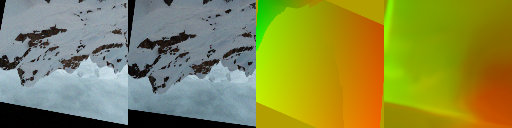

tensor(1.2359, device='cuda:0')


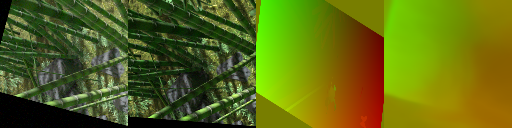

KeyboardInterrupt: 

In [36]:
import torch.nn as nn
from elasticdino.model.layers import ResidualBlock, Activation, ProjectionLayer
from elasticdino.training.depth.layers import UNet, UNet2, MyUNet

class Model(nn.Module):
    def __init__(self, n_features=256):
        super().__init__()
        self.feature_project = nn.Sequential(
            ProjectionLayer(1024, n_features),
            ResidualBlock(n_features),
            ResidualBlock(n_features),
            ResidualBlock(n_features),
            ResidualBlock(n_features),
            ResidualBlock(n_features),
        )

        self.merge = nn.Sequential(
            MyUNet(n_features * 2, n_features, n_features_out=2)
        )
        
        
    def forward(self, features1, features2):
        features = torch.cat([self.feature_project(features1), self.feature_project(features2)], dim=1)
        return self.merge(features)


from IPython.display import display
import numpy as np
from PIL import Image

def debug_step(img1, img2, flow, pred):
    fmax = torch.max(flow[0].max(), pred[0].max())
    fmin = torch.min(flow[0].min(), pred[0].min())
    def flow_img(f):
        f = (f - fmin) / (fmax - fmin)
        f = torch.cat([f, torch.zeros([1, f.shape[-1], f.shape[-1]], device=f.device, dtype=f.dtype)], dim=0)
        return torchvision.transforms.functional.to_pil_image(f)
    display(Image.fromarray(np.hstack([torchvision.transforms.functional.to_pil_image(img1[0]), 
                       torchvision.transforms.functional.to_pil_image(img2[0]), 
                       flow_img(flow[0]), 
                       flow_img(pred[0])])))



def compute_loss(f1, f2):
    loss = 0.0
    current_size = f1.shape[-1]
    while current_size > 4:
        f1 = nn.functional.interpolate(f1, current_size, mode="bilinear")
        f2 = nn.functional.interpolate(f2, current_size, mode="bilinear")
        loss += (f1 - f2).abs().mean()
        current_size //= 2
    return loss
    
def train(n_epochs=1, debug_interval=10, max_iterations=None):
    torch.set_float32_matmul_precision('medium')
    torch.backends.cudnn.benchmark = True
    
    model = Model().cuda()
    # model = torch.compile(model)
    scaler = torch.amp.GradScaler()

    
    import bitsandbytes
    optimizer = bitsandbytes.optim.AdamW8bit(
        [{"params": model.parameters(), "lr": 5e-4}], eps=1e-5, weight_decay=1e-5)
            
    n = 0
    running_loss = None

    dataloader = torch.utils.data.DataLoader(dataset, collate_fn=collate, 
                                                            batch_size=8, num_workers=16, pin_memory=True, shuffle=True)
    
    for e in range(n_epochs):
        print("epoch", e)
        for img1, img2, flow in dataloader:
            optimizer.zero_grad()
            img1 = img1.cuda(non_blocking=True)
            img2 = img2.cuda(non_blocking=True)
            flow = flow.cuda(non_blocking=True)
                
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                with torch.no_grad():
                    features1 = edino(img1)
                    features2 = edino(img2)
                pred = model(features1, features2)
                loss = compute_loss(pred, flow)
                
            scaler.scale(loss).backward()
            # scaler.unscale_(optimizer)
            # torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            
            scaler.step(optimizer)
            scaler.update()

            if running_loss is None:
                running_loss = loss.detach()
            else:
                running_loss = 0.95 * running_loss + 0.05 * loss.detach()

            n += 1
            if debug_interval is not None and n % debug_interval == 0:
                print(running_loss)
                debug_step(img1, img2, flow, pred)
                    
            if max_iterations is not None and n >= max_iterations:
                print("Max iterations reached")
                
                return
            del loss
            del pred
            del img1
            del img2
            del flow
            
train(debug_interval=50, n_epochs=100)